In [1]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score

In [2]:
df = pd.read_csv('sleep.csv')

In [3]:
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea



Столбцы набора данных:  
- ID человека: идентификатор для каждого человека.  
- Пол: пол человека (мужчина/женщина).  
- Возраст: возраст человека в годах.  
- Род занятий: род занятий или профессия человека.  
- Продолжительность сна (часы): количество часов, которые человек спит в день.  
- Качество сна (шкала: 1-10): субъективная оценка качества сна в диапазоне от 1 до 10.  
- Уровень физической активности (минут/день): количество минут, в течение которых человек занимается физической активностью ежедневно.  
- Уровень стресса (шкала: 1-10): субъективная оценка уровня стресса, испытываемого человеком, в диапазоне от 1 до 10.  
- Категория ИМТ: категория индекса массы тела человека (например, недостаточный вес, нормальный вес, избыточный вес).  
- Артериальное давление (систолическое/диастолическое): измерение артериального давления человека, указанное как систолическое давление над диастолическим давлением.  
- Частота сердечных сокращений (уд/мин): частота сердечных сокращений человека в состоянии покоя в ударах в минуту.  
- Ежедневные шаги: количество шагов, которые человек делает за день.  
- Нарушение сна: наличие или отсутствие нарушения сна у человека (отсутствует, бессонница, апноэ во сне).  


### **Выделим и предобработаем целевую переменную: нарушение сна**

In [4]:
df['Sleep Disorder'].unique()

array([nan, 'Sleep Apnea', 'Insomnia'], dtype=object)

**Заменим nan на 'doesn't have'**

In [5]:
df['Sleep Disorder'] = df['Sleep Disorder'].fillna("doesn't have")
df['Sleep Disorder'].unique()

array(["doesn't have", 'Sleep Apnea', 'Insomnia'], dtype=object)

In [6]:
sleep_dic = {'Insomnia': 0, "doesn't have":1, 'Sleep Apnea':2}
df['Sleep Disorder'] = df['Sleep Disorder'].map(sleep_dic)

In [7]:
Y = df['Sleep Disorder']
df = df.drop('Sleep Disorder', axis=1)

### **Предобработаю данные**

**Удалю незначащую колокнку с айди и преобразую гендер к бинарному числовому, а не текстовому виду**

In [8]:
df = df.drop('Person ID', axis=1)

In [9]:
df['Gender'] = df['Gender'].map({"Male":0, "Female":1})

In [10]:
df.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps
0,0,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200
1,0,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000
2,0,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000
3,0,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000
4,0,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000


**Разобью возраст на категории по 5 лет, тк идейно, что 23, что 24. Разницы большой нет (влияет не возраст в пределах 5 лет, а показатели организма)** 

In [11]:
print(df['Age'].min(), df['Age'].max())

27 59


In [12]:
groups = []
for i in range(df['Age'].min() - 1, df['Age'].max() + 5, 5):
    groups.append(i)
groups_cut = pd.cut(df['Age'].values, groups)
df['Age'] = groups_cut.codes

In [13]:
print(df['Age'].min(), df['Age'].max())

0 6


In [14]:
df.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps
0,0,0,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200
1,0,0,Doctor,6.2,6,60,8,Normal,125/80,75,10000
2,0,0,Doctor,6.2,6,60,8,Normal,125/80,75,10000
3,0,0,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000
4,0,0,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000


In [15]:
df['Occupation'].unique()

array(['Software Engineer', 'Doctor', 'Sales Representative', 'Teacher',
       'Nurse', 'Engineer', 'Accountant', 'Scientist', 'Lawyer',
       'Salesperson', 'Manager'], dtype=object)

**Нельзя как-то эмпирически разделить эти профессии однозначно, поэтому воспользуюсь просто лейбл декодером**

In [16]:

le = LabelEncoder()
le.fit(df['Occupation'].unique())
le.classes_

array(['Accountant', 'Doctor', 'Engineer', 'Lawyer', 'Manager', 'Nurse',
       'Sales Representative', 'Salesperson', 'Scientist',
       'Software Engineer', 'Teacher'], dtype=object)

In [17]:
df['Occupation'] = le.transform(df['Occupation'])

In [18]:
df.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps
0,0,0,9,6.1,6,42,6,Overweight,126/83,77,4200
1,0,0,1,6.2,6,60,8,Normal,125/80,75,10000
2,0,0,1,6.2,6,60,8,Normal,125/80,75,10000
3,0,0,6,5.9,4,30,8,Obese,140/90,85,3000
4,0,0,6,5.9,4,30,8,Obese,140/90,85,3000


**Разобьем сон на группы с ходом 0.5 (фазы сна)**

In [19]:
print(df['Sleep Duration'].min(), df['Sleep Duration'].max())

5.8 8.5


In [20]:
df['Sleep Duration'] = df['Sleep Duration'] * 10

In [21]:
groups = []
for i in range(54, 90, 5):
    groups.append(i)
groups_cut = pd.cut(df['Sleep Duration'].values, groups)
df['Sleep Duration'] = groups_cut.codes

In [22]:
df.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps
0,0,0,9,1,6,42,6,Overweight,126/83,77,4200
1,0,0,1,1,6,60,8,Normal,125/80,75,10000
2,0,0,1,1,6,60,8,Normal,125/80,75,10000
3,0,0,6,0,4,30,8,Obese,140/90,85,3000
4,0,0,6,0,4,30,8,Obese,140/90,85,3000


**Закодирую Категория ИМТ**

In [23]:
le2 = LabelEncoder()
le2.fit(df['BMI Category'].unique())
df['BMI Category'] = le2.transform(df['BMI Category'])

In [24]:
df.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps
0,0,0,9,1,6,42,6,3,126/83,77,4200
1,0,0,1,1,6,60,8,0,125/80,75,10000
2,0,0,1,1,6,60,8,0,125/80,75,10000
3,0,0,6,0,4,30,8,2,140/90,85,3000
4,0,0,6,0,4,30,8,2,140/90,85,3000


**Предобработаю давление**

In [25]:
df[['Systolic', 'Diastolic']] = df['Blood Pressure'].str.split('/', expand=True)

In [26]:
df.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Systolic,Diastolic
0,0,0,9,1,6,42,6,3,126/83,77,4200,126,83
1,0,0,1,1,6,60,8,0,125/80,75,10000,125,80
2,0,0,1,1,6,60,8,0,125/80,75,10000,125,80
3,0,0,6,0,4,30,8,2,140/90,85,3000,140,90
4,0,0,6,0,4,30,8,2,140/90,85,3000,140,90


In [27]:
df['Systolic'] = df['Systolic'].astype(int)
df['Diastolic'] = df['Diastolic'].astype(int)

In [28]:
def determine_pressure_status(row):
    systolic = row['Systolic']
    diastolic = row['Diastolic']
    if systolic < 90 or diastolic < 60:
        return -1  # Пониженное давление
    elif systolic > 120 or diastolic > 80:
        return 1   # Повышенное давление
    else:
        return 0   # Нормальное давление
df['PressureStatus'] = df.apply(determine_pressure_status, axis=1)

In [29]:
df = df.drop(['Blood Pressure', 'Systolic', 'Diastolic'], axis=1)


In [30]:
df['Daily Steps'].unique()

array([ 4200, 10000,  3000,  3500,  8000,  4000,  4100,  6800,  5000,
        7000,  5500,  5200,  5600,  3300,  4800,  7500,  7300,  6200,
        6000,  3700])

In [31]:
df.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,PressureStatus
0,0,0,9,1,6,42,6,3,77,4200,1
1,0,0,1,1,6,60,8,0,75,10000,1
2,0,0,1,1,6,60,8,0,75,10000,1
3,0,0,6,0,4,30,8,2,85,3000,1
4,0,0,6,0,4,30,8,2,85,3000,1


**Проверим на наличие пропусков в данных**

In [32]:
df.isna().sum()

Gender                     0
Age                        0
Occupation                 0
Sleep Duration             0
Quality of Sleep           0
Physical Activity Level    0
Stress Level               0
BMI Category               0
Heart Rate                 0
Daily Steps                0
PressureStatus             0
dtype: int64

## **Разобью данные на тренировочные и тестовые**

In [33]:
x_train, x_test, y_train, y_test = train_test_split(df, Y, random_state=100, test_size=0.3)

## **Применю ново изученные методы**

### **Голосование большинством**

In [47]:
from sklearn.ensemble import VotingClassifier
from sklearn.compose import ColumnTransformer, make_column_selector

In [48]:
scale_features = ["Physical Activity Level", "Heart Rate", "Daily Steps", "Quality of Sleep", "Sleep Duration"]
preprocessor = ColumnTransformer([
    ('scaler', StandardScaler(), scale_features)
], remainder='passthrough')  # Оставляем остальные признаки без изменений'
pipeline1 = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=10000))
])
pipeline2 = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=7)) 
])
pipeline3 = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=6, random_state=42)) 
])
eclf = VotingClassifier(estimators=[('lr', pipeline1), ('knn', pipeline2), ('dt', pipeline3)], voting='hard')
eclf.fit(x_train, y_train)
train_predict = eclf.predict(x_train)
test_predict = eclf.predict(x_test)

In [49]:
print(f1_score(y_train, train_predict, average = 'macro'))
print(f1_score(y_test, test_predict, average = 'macro'))

0.897843352955174
0.8686948222381292


In [50]:
from sklearn.model_selection import GridSearchCV

param_grid_lr = {
    'classifier__C': [0.01, 0.04, 0.03, 0.1, 1, 10, 100],
    'classifier__max_iter': [5000, 10000, 20000]
}
param_grid_knn = {
    'classifier__n_neighbors': [i for i in range(2, 11)],
    'classifier__weights': ['uniform', 'distance']
}
param_grid_dt = {
    'classifier__max_depth': [i for i in range(2, 10)],
    'classifier__min_samples_split': [2, 5, 10]
}
grid_lr = GridSearchCV(pipeline1, param_grid_lr, cv=5, scoring='f1_macro') #cv-число фолдов на кросс-валидации
grid_knn = GridSearchCV(pipeline2, param_grid_knn, cv=5, scoring='f1_macro')
grid_dt = GridSearchCV(pipeline3, param_grid_dt, cv=5, scoring='f1_macro')

best_lr = grid_lr.fit(x_train, y_train).best_estimator_
best_knn = grid_knn.fit(x_train, y_train).best_estimator_
best_dt = grid_dt.fit(x_train, y_train).best_estimator_

eclf = VotingClassifier(estimators=[('lr', best_lr), ('knn', best_knn), ('dt', best_dt)], voting='hard')
eclf.fit(x_train, y_train)

train_predict = eclf.predict(x_train)
test_predict = eclf.predict(x_test)

print(f1_score(y_train, train_predict, average='macro'))
print(f1_score(y_test, test_predict, average='macro'))


0.9122441923412797
0.9032370953630796


C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\ma\core.py:2881: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


**Попробую voting-soft**

In [51]:
eclf = VotingClassifier(estimators=[('lr', pipeline1), ('knn', pipeline2), ('dt', pipeline3)], voting='soft')
eclf.fit(x_train, y_train)
train_predict = eclf.predict(x_train)
test_predict = eclf.predict(x_test)
print(f1_score(y_train, train_predict, average = 'macro'))
print(f1_score(y_test, test_predict, average = 'macro'))

0.9122441923412797
0.8890956812216655


In [52]:
eclf = VotingClassifier(estimators=[('lr', best_lr), ('knn', best_knn), ('dt', best_dt)], voting='soft')
eclf.fit(x_train, y_train)

train_predict = eclf.predict(x_train)
test_predict = eclf.predict(x_test)

print(f1_score(y_train, train_predict, average='macro'))
print(f1_score(y_test, test_predict, average='macro'))

0.9122441923412797
0.9032370953630796


In [53]:
pred_lr = best_lr.predict(x_test)
pred_knn = best_knn.predict(x_test)
pred_dt = best_dt.predict(x_test)
pred_ensemble = eclf.predict(x_test)

# Подсчет совпадений каждой модели с ансамблевым решением
print("Совпадение с LogisticRegression:", (pred_lr == pred_ensemble).mean())
print("Совпадение с KNeighborsClassifier:", (pred_knn == pred_ensemble).mean())
print("Совпадение с DecisionTreeClassifier:", (pred_dt == pred_ensemble).mean())

Совпадение с LogisticRegression: 0.9469026548672567
Совпадение с KNeighborsClassifier: 0.9911504424778761
Совпадение с DecisionTreeClassifier: 0.9911504424778761


### **Случайный лес**

In [54]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV

clf = RandomForestClassifier(random_state=0)
param_grid = {
    'n_estimators': [i for i in range(1, 14)], # число деревьев
    'max_features': [i for i in range(1, 11)]   #число признаков
}
grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='f1_macro')
grid_search.fit(x_train, y_train)
best_clf = grid_search.best_estimator_

train_predict = best_clf.predict(x_train)
test_predict = best_clf.predict(x_test)

print(f1_score(y_train, train_predict, average='macro'))
print(f1_score(y_test, test_predict, average='macro'))


0.9122441923412797
0.9141936968023924


### **Значимость признаков**

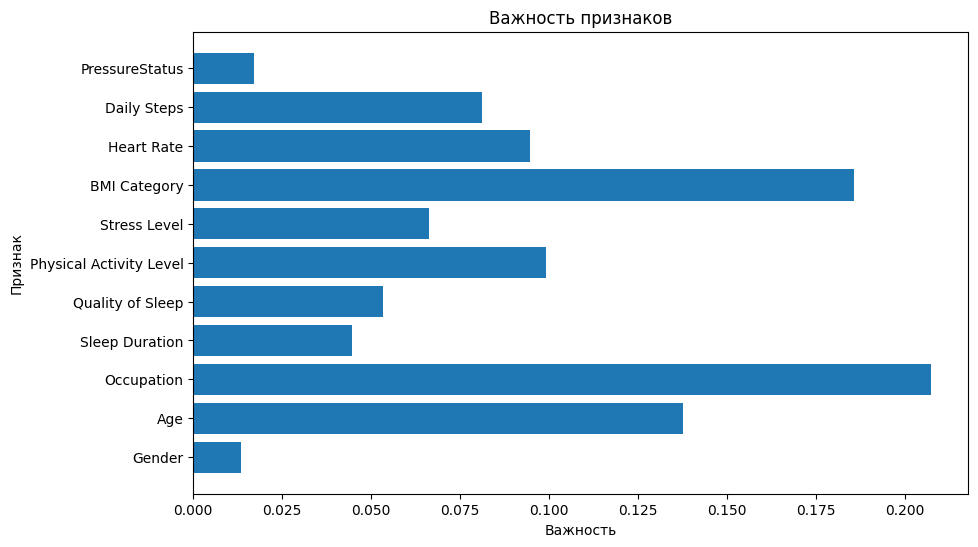

In [55]:
import matplotlib.pyplot as plt
importances = best_clf.feature_importances_
plt.figure(figsize=(10,6))
plt.barh(x_test.columns, importances)
plt.xlabel('Важность')
plt.ylabel('Признак')
plt.title('Важность признаков')
plt.show()

In [56]:
x_test_2 = x_test.drop('Gender', axis=1)
x_train_2 = x_train.drop('Gender', axis=1)

In [57]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV

clf = RandomForestClassifier(random_state=0)
param_grid = {
    'n_estimators': [i for i in range(1, 14)], # число деревьев
    'max_features': [i for i in range(1, 11)]   #число признаков
}
grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='f1_macro')
grid_search.fit(x_train_2, y_train)
best_clf = grid_search.best_estimator_

train_predict = best_clf.predict(x_train_2)
test_predict = best_clf.predict(x_test_2)

print(f1_score(y_train, train_predict, average='macro'))
print(f1_score(y_test, test_predict, average='macro'))

0.9122441923412797
0.8890956812216655


C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\ma\core.py:2881: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Хоть значимость и мала, но дропать не стоит, потому что качество не улучшает

### **Бэггинг**

In [62]:
from sklearn.ensemble import BaggingClassifier
bagging_clf = BaggingClassifier(estimator=DecisionTreeClassifier(), random_state=0)
param_grid = {
    'n_estimators': list(range(1, 15))
}
grid_search = GridSearchCV(bagging_clf, param_grid, cv=5, scoring='f1_macro')
grid_search.fit(x_train, y_train)
best_clf = grid_search.best_estimator_
train_predict = best_clf.predict(x_train)
test_predict = best_clf.predict(x_test)
print(f1_score(y_train, train_predict, average='macro'))
print(f1_score(y_test, test_predict, average='macro'))

0.9122441923412797
0.8951418951418951


### **Бустинг**

In [85]:
from sklearn.ensemble import GradientBoostingClassifier

clf = GradientBoostingClassifier(n_estimators=20)
clf.fit(x_train, y_train)
train_predict = clf.predict(x_train)
test_predict = clf.predict(x_test)
print(f1_score(y_train, train_predict, average='macro'))
print(f1_score(y_test, test_predict, average='macro'))

0.9122441923412797
0.9004329004329005


In [87]:
param_grid = {
    'n_estimators': [2, 10, 20, 50, 100],
    'learning_rate': [0.01, 0.1, 0.2, 0.5, 0.7,1, 2]
}
gb_clf = GradientBoostingClassifier(random_state=0)
grid_search = GridSearchCV(gb_clf, param_grid, cv=5, scoring='f1_macro')
grid_search.fit(x_train, y_train)

best_clf = grid_search.best_estimator_

train_predict = best_clf.predict(x_train)
test_predict = best_clf.predict(x_test)

print(f1_score(y_train, train_predict, average='macro'))
print(f1_score(y_test, test_predict, average='macro'))

0.9122441923412797
0.9004329004329005


In [109]:
pip install xgboost


[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/124.9 MB 4.2 MB/s eta 0:00:30
   ---------------------------------------- 1.0/124.9 MB 3.1 MB/s eta 0:00:40
    --------------------------------------- 1.6/124.9 MB 3.0 MB/s eta 0:00:42
    --------------------------------------- 2.6/124.9 MB 3.5 MB/s eta 0:00:35
   - -------------------------------------- 3.7/124.9 MB 3.9 MB/s eta 0:00:32
   - -------------------------------------- 4.7/124.9 MB 4.1 MB/s eta 0:00:30
   - -------------------------------------- 5.5/124.9 MB 4.4 MB/s eta 0:00:28
   -- ------------------------------------- 6.6/124.9 MB 4.2 MB/s eta 0:00:29
   -- ------------------------------------- 8.1/124.9 MB 4.5 MB/s eta 0:00:26
   --- ------------------------------------ 9.7/124.9 MB 4.8 MB/s eta 0:00:24
   --- ------------------------------------ 11.3/124.9 MB 5.1 MB/s eta 0:00:23
   ---- ----------------------------------- 12.8/124.9 MB 5.3 MB/s et

In [119]:
from xgboost import XGBClassifier
from sklearn.metrics import f1_score

clf = XGBClassifier(n_estimators=5)

clf.fit(x_train, y_train)

train_predict = clf.predict(x_train)
test_predict = clf.predict(x_test)

print(f1_score(y_train, train_predict, average='macro'))
print(f1_score(y_test, test_predict, average='macro'))

0.907635985260706
0.8902433707414481


### **Стекинг**

In [89]:
from sklearn.ensemble import StackingClassifier

In [107]:
elcf = StackingClassifier(
    estimators=[
        ('knn', pipeline2), 
        ('tree', pipeline3)
    ],
    final_estimator=LogisticRegression(C=0.1)  
)
elcf.fit(x_train,y_train)
train_predict = elcf.predict(x_train)
test_predict = elcf.predict(x_test)

print(f1_score(y_train, train_predict, average='macro'))
print(f1_score(y_test, test_predict, average='macro'))

0.9029624085922302
0.8957795004306632
